In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from typing import Annotated, Any, Union, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field


from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

/Users/abinashpant/Codes/projects/agents_basesetup/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

llm = ChatGoogleGenerativeAI(
    model='gemini-2.0-flash-exp',
    api_key=os.getenv('GEMINI_API_KEY')
)

graph_builder = StateGraph(State)

In [3]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def subtract(a: int, b: int) -> int:
    """Subtracts b from a.

    Args:
        a: first int (minuend)
        b: second int (subtrahend)
    """
    return a - b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

math_tools = [add, subtract, multiply, divide]
llm_with_math_tools = llm.bind_tools(math_tools)

In [4]:
def math_tools_condition(
    state: Union[list[AnyMessage], dict[str, Any], BaseModel],
    messages_key: str = "messages",
) -> Literal["requires_math_tools", "no_tool_required"]:
    
    if isinstance(state, list):
        ai_message = state[-1]
    elif isinstance(state, dict) and (messages := state.get(messages_key, [])):
        ai_message = messages[-1]
    elif messages := getattr(state, messages_key, []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "requires_math_tools"
    return "no_tool_required"

In [5]:
def get_query(state:State):
    return {"message": state["message"]}

def math_ai(state: State):
    return {"messages": [llm_with_math_tools.invoke(state["messages"])]}

In [ ]:
# Reset the graph builder
graph_builder = StateGraph(State)
graph_builder.add_node("get_query",get_query)
graph_builder.add_node("chat_bot",math_ai)
graph_builder.add_node("math_tools", ToolNode(math_tools))

graph_builder.add_edge(START, "get_query") 
graph_builder.add_edge("get_query", "chat_bot")
graph_builder.add_edge("chat_bot","math_tools")
# graph_builder.add_conditional_edges(
#     "chat_bot",
#     math_tools_condition,
#     {
#         'requires_math_tools': 'math_tools',
#         #'no_tool_required': END
#     })
graph_builder.add_edge("math_tools", "chat_bot")
graph_builder.add_edge("chat_bot", END)

# Compile the graph
graph = graph_builder.compile()


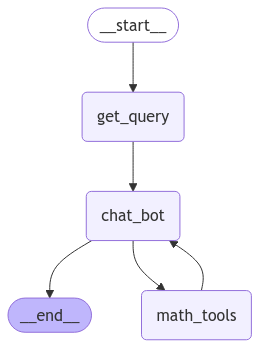

In [7]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))